# 99. Black-Litterman Baseline

## 논문 구현 (Pyo & Lee, 2018)
변동성 예측 없이 **현재 vol_21d로 직접 분류**한 baseline BL 포트폴리오.

## 전체 흐름
```
[Step 1] 자산 분류 (Baseline: 현재 vol_21d 직접 사용)
   ├── vol_21d 오름차순 정렬
   ├── 하위 30% → 저위험 (long)
   └── 상위 30% → 고위험 (short)

[Step 2] 뷰 포트폴리오 구성
   ├── P: 시총 가중 (저위험 +, 고위험 -)
   ├── Q: Fama-French 3팩터로 추정한 기대수익률 → q = P·r̂
   └── Ω: He-Litterman 공식 (τ·P·Σ·P^T)

[Step 3] BL 사후 (Sherman-Woodbury)
   └── μ_BL = Π + τΣP^T[P(τΣ)P^T + Ω]^{-1}(q - PΠ)

[Step 4] 포트폴리오 최적화
   └── min (λ/2)w^T Σ w - w^T μ_BL
       s.t. Σw=1, w≥0
```

## 비교 대상
- **BL (Baseline)**: 현재 vol_21d 분류 → BL 최적화
- **CAPM 균형**: BL 없이 μ=Π 그대로 최적화
- **S&P 500 (SPY)**: 시장 지수

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import io, re, zipfile, requests
import warnings
import platform
from pathlib import Path
from sklearn.covariance import LedoitWolf
from sklearn.linear_model import LinearRegression
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs' / '99_baseline'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 파라미터 ────────────────────────────────────────────────
TRAIN_WINDOW  = 60    # 개월 (일별 ≈ 1260 거래일)
THRESH_DAILY  = 0.9   # 일별 공분산 유효 티커 기준 (90%)
TAU           = 0.1
PCT_GROUP     = 0.30
START_PRED    = '2010-01-01'
LAM_FIXED     = 2.5
MAX_WEIGHT    = 0.10  # 단일 종목 최대 비중 (1.0 = 제약 없음)

# ── 데이터 로드 ──────────────────────────────────────────────
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])

daily_ret = pd.read_pickle(DATA_DIR / 'daily_returns.pkl')

all_dates  = panel.index.get_level_values('date').unique().sort_values()
pred_dates = all_dates[all_dates >= START_PRED]

print(f'패널       : {panel.shape}')
print(f'일별 수익률: {daily_ret.shape}')
print(f'예측 기간  : {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'MAX_WEIGHT : {MAX_WEIGHT:.0%}')

패널       : (97944, 11)
일별 수익률: (5595, 822)
예측 기간  : 2010-01-31 ~ 2024-12-31 (180개월)
MAX_WEIGHT : 10%


In [2]:
# ── FF3 팩터 로드 (02에서 저장한 파일 재사용) ────────────────
FF3_PATH = DATA_DIR / 'ff3_monthly.csv'

def download_ff3():
    url = ('https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/'
           'F-F_Research_Data_Factors_CSV.zip')
    resp = requests.get(url, timeout=60)
    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        raw = zf.read(zf.namelist()[0]).decode('utf-8', errors='ignore')
    lines = raw.splitlines()
    start = next(i for i, l in enumerate(lines) if re.match(r'^\s*\d{6}\s*,', l))
    end   = next((i for i in range(start, len(lines))
                  if not re.match(r'^\s*\d{6}\s*,', lines[i])), len(lines))
    df = pd.read_csv(io.StringIO('\n'.join(lines[start-1:end])))
    df.columns = [c.strip() for c in df.columns]
    date_col = df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col].astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)
    df = df.rename(columns={date_col: 'date', 'Mkt-RF': 'mkt_rf',
                             'SMB': 'smb', 'HML': 'hml', 'RF': 'rf'})
    return df.set_index('date').astype(float) / 100.0

if FF3_PATH.exists():
    ff3 = pd.read_csv(FF3_PATH, index_col='date', parse_dates=True)
    print(f'FF3 로드: {ff3.shape}')
else:
    print('FF3 다운로드 중...')
    ff3 = download_ff3()
    ff3.to_csv(FF3_PATH)
    print(f'FF3 저장: {ff3.shape}')

print(ff3.tail(3))

FF3 로드: (1196, 4)
            mkt_rf     smb     hml      rf
date                                      
2025-12-31 -0.0036 -0.0106  0.0242  0.0034
2026-01-31  0.0102  0.0220  0.0372  0.0030
2026-02-28 -0.0117  0.0014  0.0283  0.0028


In [3]:
# ── BL 구성 함수들 ───────────────────────────────────────────

def compute_sigma(ret_matrix, scale=1.0):
    lw  = LedoitWolf().fit(ret_matrix.values)
    cov = lw.covariance_ * scale
    return pd.DataFrame(cov, index=ret_matrix.columns, columns=ret_matrix.columns)


def compute_daily_slice(pred_date, universe):
    start  = pred_date - pd.DateOffset(months=TRAIN_WINDOW)
    window = daily_ret.loc[start:pred_date, [t for t in universe if t in daily_ret.columns]]
    T      = len(window)
    thresh = int(T * THRESH_DAILY)
    valid  = window.columns[window.notna().sum() >= thresh]
    return window[valid].fillna(0), valid.tolist()


def compute_pi(Sigma, w_mkt, spy_excess_ret, sigma2_mkt):
    if LAM_FIXED is not None:
        lam = LAM_FIXED
    else:
        lam = spy_excess_ret / sigma2_mkt if sigma2_mkt > 0 else 2.5
        lam = np.clip(lam, 0.5, 10.0)
    return lam * Sigma @ w_mkt, lam


def build_P(vol_series, mcap_series, pct=0.30):
    n_group    = max(1, int(len(vol_series) * pct))
    sorted_idx = vol_series.sort_values().index
    low_risk   = sorted_idx[:n_group]
    high_risk  = sorted_idx[-n_group:]
    P = pd.Series(0.0, index=vol_series.index)
    low_m  = mcap_series[low_risk]
    high_m = mcap_series[high_risk]
    P[low_risk]  =  low_m  / low_m.sum()
    P[high_risk] = -high_m / high_m.sum()
    return P


def compute_Q_ff3(P, ret_matrix, ff3_train, rf_train):
    view_tickers = [t for t in P[P != 0].index if t in ret_matrix.columns]
    if not view_tickers:
        return 0.0
    ff3_aligned = ff3_train.reindex(ret_matrix.index).dropna()
    rf_aligned  = rf_train.reindex(ff3_aligned.index).fillna(0)
    n = len(ff3_aligned)
    if n < 24:
        return 0.0
    X      = np.column_stack([np.ones(n), ff3_aligned[['mkt_rf', 'smb', 'hml']].values])
    X_next = np.array([1.0] + ff3_aligned[['mkt_rf', 'smb', 'hml']].mean().tolist())
    rf_next = float(rf_train.iloc[-1]) if len(rf_train) > 0 else 0.0
    r_hat_excess = np.zeros(len(view_tickers))
    for j, t in enumerate(view_tickers):
        y = ret_matrix[t].reindex(ff3_aligned.index) - rf_aligned
        valid = y.notna()
        if valid.sum() < 12:
            continue
        coef_j = np.linalg.lstsq(X[valid], y[valid].values, rcond=None)[0]
        r_hat_excess[j] = float(X_next @ coef_j)
    r_hat = pd.Series(0.0, index=ret_matrix.columns)
    for j, t in enumerate(view_tickers):
        r_hat[t] = r_hat_excess[j] + rf_next
    return float(P.reindex(ret_matrix.columns).fillna(0) @ r_hat)


def compute_omega(P, Sigma, tau):
    p = P.values
    return max(float(tau * p @ Sigma.values @ p), 1e-8)


def black_litterman(pi, Sigma, P, q, omega, tau):
    p    = P.values
    pi_v = pi.values
    tSig = tau * Sigma.values
    M      = float(p @ tSig @ p) + omega
    diff   = q - float(p @ pi_v)
    adjust = tSig @ p * (diff / M)
    return pd.Series(pi_v + adjust, index=pi.index)


def optimize_portfolio(mu_BL, Sigma, lam, max_weight=None):
    """
    max_weight: 단일 종목 최대 비중 (None이면 MAX_WEIGHT 전역변수 사용)
    실험 시 max_weight=1.0으로 호출하면 제약 없음
    """
    if max_weight is None:
        max_weight = MAX_WEIGHT
    n   = len(mu_BL)
    mu  = mu_BL.values
    Sig = Sigma.values
    def obj(w): return 0.5 * lam * w @ Sig @ w - w @ mu
    def jac(w): return lam * Sig @ w - mu
    res = minimize(obj, np.ones(n)/n, jac=jac, method='SLSQP',
                   bounds=[(0, max_weight)] * n,
                   constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}])
    w = res.x if res.success else np.ones(n) / n
    return pd.Series(w, index=mu_BL.index)


print('BL 함수 정의 완료')
print(f'  공분산    : 일별 LW × 21 → 월별 단위')
print(f'  MAX_WEIGHT: {MAX_WEIGHT:.0%} (단일 종목 상한)')
print(f'  thresh    : {THRESH_DAILY:.0%}')

def compute_Q_realized(P, ret_pivot, pred_date, window=None):
    w = window or TRAIN_WINDOW
    start = pred_date - pd.DateOffset(months=w)
    avail = [t for t in P[P != 0].index if t in ret_pivot.columns]
    if not avail: return Q_FIXED
    rets = ret_pivot.loc[start:pred_date, avail].dropna(how="all")
    if len(rets) < 6: return Q_FIXED
    P_sub = P.reindex(rets.columns).fillna(0)
    return max(float((rets @ P_sub).mean()), 0.0)


BL 함수 정의 완료
  공분산    : 일별 LW × 21 → 월별 단위
  MAX_WEIGHT: 10% (단일 종목 상한)
  thresh    : 90%


Ledoit-Wolf 진단 요약 (일별 공분산, ×21 스케일)
p (종목 수):     416개 평균  (min 342 ~ max 481)
T (일별 거래일): 1259개 평균
p/T 비율:        0.33 평균  (min 0.27 ~ max 0.38)
LW α (수축강도): 0.019 평균  (min 0.009 ~ max 0.042)
최소 고유값:     3.57e-04 평균
유효 랭크:       6.9 평균  (종목 수 대비 1.7%)

✓  α=0.019 → 공분산 구조 적절히 반영.

[비교] 98_baseline 월별 T=36:  p/T≈10.9, 유효랭크≈17/416
[현재] 99_baseline 일별 T=1259: p/T≈0.33, 유효랭크≈7/416


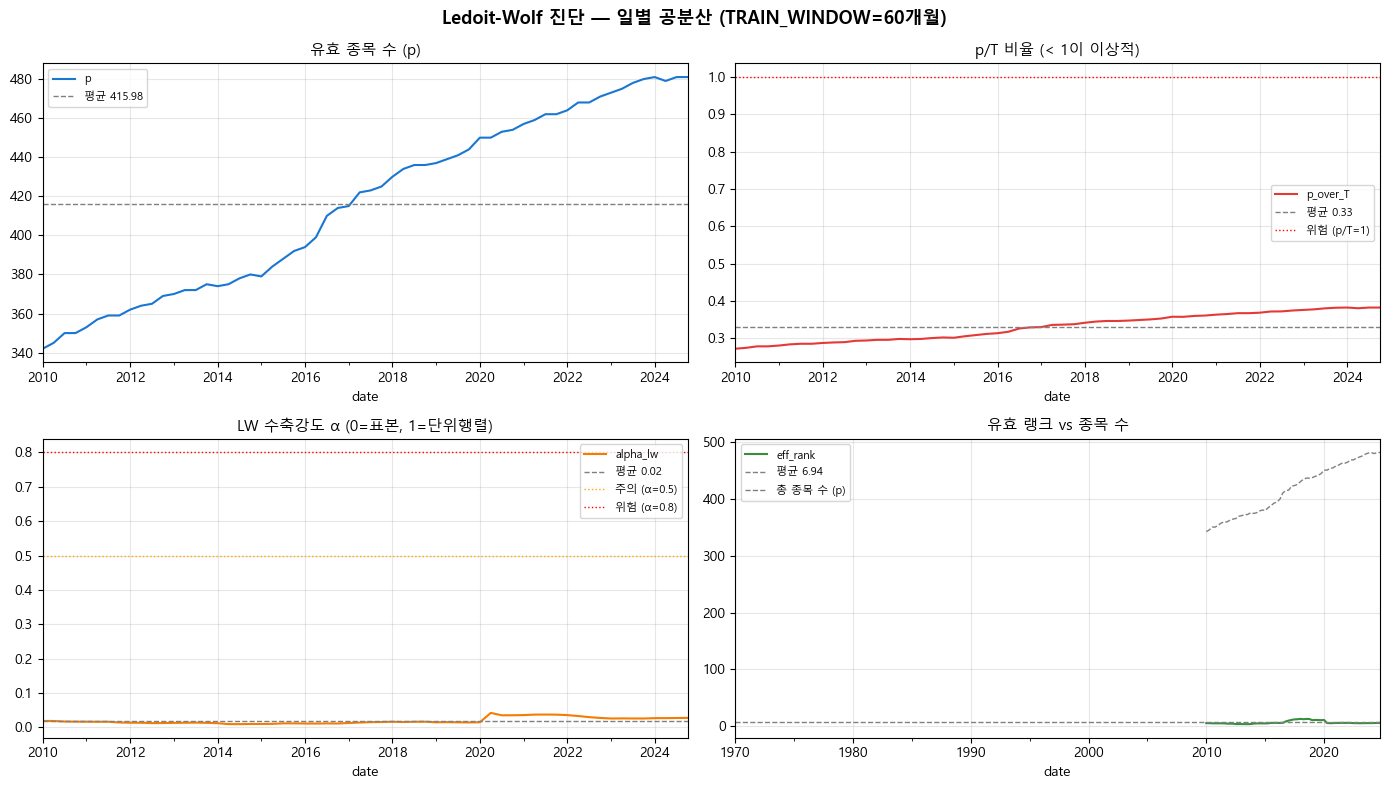

저장 완료: lw_diagnostics_daily.png


In [4]:
# ── Ledoit-Wolf 진단 (일별 공분산 기준) ──────────────────────
diag_log = []
SAMPLE_EVERY = 3

for i, pred_date in enumerate(pred_dates):
    if i % SAMPLE_EVERY != 0:
        continue
    try:
        month_df = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_df) < 30:
            continue
        daily_slice, valid_tix = compute_daily_slice(pred_date, month_df.index.tolist())
        if len(valid_tix) < 20:
            continue

        T, p  = daily_slice.shape
        lw    = LedoitWolf().fit(daily_slice.values)
        alpha = lw.shrinkage_
        eigvals  = np.linalg.eigvalsh(lw.covariance_ * 21)
        eff_rank = float(eigvals.sum()**2 / (eigvals**2).sum())

        diag_log.append({
            'date'      : pred_date,
            'T'         : T,
            'p'         : p,
            'p_over_T'  : p / T,
            'alpha_lw'  : alpha,
            'min_eigval': float(eigvals.min()),
            'eff_rank'  : eff_rank,
        })
    except Exception as e:
        print(f'[진단 에러] {pred_date.date()}: {e}')

diag = pd.DataFrame(diag_log).set_index('date')

# ── 요약 출력 ────────────────────────────────────────────────
print('=' * 55)
print('Ledoit-Wolf 진단 요약 (일별 공분산, ×21 스케일)')
print('=' * 55)
print(f"p (종목 수):     {diag['p'].mean():.0f}개 평균  (min {diag['p'].min():.0f} ~ max {diag['p'].max():.0f})")
print(f"T (일별 거래일): {diag['T'].mean():.0f}개 평균")
print(f"p/T 비율:        {diag['p_over_T'].mean():.2f} 평균  (min {diag['p_over_T'].min():.2f} ~ max {diag['p_over_T'].max():.2f})")
print(f"LW α (수축강도): {diag['alpha_lw'].mean():.3f} 평균  (min {diag['alpha_lw'].min():.3f} ~ max {diag['alpha_lw'].max():.3f})")
print(f"최소 고유값:     {diag['min_eigval'].mean():.2e} 평균")
print(f"유효 랭크:       {diag['eff_rank'].mean():.1f} 평균  (종목 수 대비 {diag['eff_rank'].mean()/diag['p'].mean():.1%})")
print()
alpha_mean = diag['alpha_lw'].mean()
if alpha_mean > 0.8:
    print(f'⚠  α={alpha_mean:.3f} → 사실상 단위행렬. 공분산 구조 거의 무시됨.')
elif alpha_mean > 0.5:
    print(f'△  α={alpha_mean:.3f} → 수축 강함. 공분산 구조 일부만 반영.')
else:
    print(f'✓  α={alpha_mean:.3f} → 공분산 구조 적절히 반영.')
print()
print(f'[비교] 98_baseline 월별 T=36:  p/T≈10.9, 유효랭크≈17/{diag["p"].mean():.0f}')
print(f'[현재] 99_baseline 일별 T={diag["T"].mean():.0f}: p/T≈{diag["p_over_T"].mean():.2f}, 유효랭크≈{diag["eff_rank"].mean():.0f}/{diag["p"].mean():.0f}')

# ── 시각화 ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f'Ledoit-Wolf 진단 — 일별 공분산 (TRAIN_WINDOW={TRAIN_WINDOW}개월)', fontsize=13, fontweight='bold')

for ax, col, title, color in [
    (axes[0,0], 'p',        '유효 종목 수 (p)',                   '#1976D2'),
    (axes[0,1], 'p_over_T', 'p/T 비율 (< 1이 이상적)',            '#E53935'),
    (axes[1,0], 'alpha_lw', 'LW 수축강도 α (0=표본, 1=단위행렬)', '#F57C00'),
    (axes[1,1], 'eff_rank', '유효 랭크 vs 종목 수',               '#388E3C'),
]:
    diag[col].plot(ax=ax, color=color, linewidth=1.5)
    ax.axhline(diag[col].mean(), color='gray', linestyle='--', linewidth=1,
               label=f'평균 {diag[col].mean():.2f}')
    if col == 'alpha_lw':
        ax.axhline(0.5, color='orange', linestyle=':', linewidth=1, label='주의 (α=0.5)')
        ax.axhline(0.8, color='red',    linestyle=':', linewidth=1, label='위험 (α=0.8)')
    if col == 'p_over_T':
        ax.axhline(1.0, color='red', linestyle=':', linewidth=1, label='위험 (p/T=1)')
    if col == 'eff_rank':
        diag['p'].plot(ax=ax, color='gray', linewidth=1.0, linestyle='--', label='총 종목 수 (p)')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'lw_diagnostics_daily.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: lw_diagnostics_daily.png')

In [5]:
# ── 루프 밖: 한 번만 계산 ────────────────────────────────────
spy_series = panel['spy_ret'].groupby(level='date').first()
rf_series  = panel['rf_1m'].groupby(level='date').first()

Q_FIXED = 0.003
print(f'Q_FIXED = {Q_FIXED}  (월 {Q_FIXED*100:.1f}%  |  연 {Q_FIXED*12*100:.1f}%)')

# ── Walk-forward ─────────────────────────────────────────────
bl_returns, capm_returns, spy_returns, error_log = [], [], [], []
composition_log = []
print(f'Walk-forward: {pred_dates[0].date()} ~ {pred_dates[-1].date()}')

for i, pred_date in enumerate(pred_dates):
    if (i + 1) % 12 == 0:
        print(f'  {pred_date.date()} ({i+1}/{len(pred_dates)})')

    try:
        month_df = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_df) < 30:
            continue
        universe = month_df.index.tolist()

        # ── 일별 공분산 (월별 단위로 스케일) ──────────────────
        daily_slice, valid_tix = compute_daily_slice(pred_date, universe)
        if len(valid_tix) < 20:
            continue

        Sigma = compute_sigma(daily_slice, scale=21)

        month_df = month_df.reindex(valid_tix)
        mcap     = np.exp(month_df['log_mcap'])
        w_mkt    = (mcap / mcap.sum()).reindex(valid_tix).fillna(0)

        idx         = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
        spy_s       = spy_series.reindex(train_dates)
        rf_s        = rf_series.reindex(train_dates)
        spy_excess  = (spy_s - rf_s).mean()
        sigma2_mkt  = spy_s.var()

        pi, lam = compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt)

        P = build_P(month_df['vol_21d'], mcap, pct=PCT_GROUP)
        P = P.reindex(valid_tix).fillna(0)

        omega = compute_omega(P, Sigma, TAU)
        mu_BL = black_litterman(pi, Sigma, P, Q_FIXED, omega, TAU)

        w_bl   = optimize_portfolio(mu_BL, Sigma, lam)
        w_capm = optimize_portfolio(pi,    Sigma, lam)

        actual_ret = month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0)
        next_date  = all_dates[idx + 1] if idx + 1 < len(all_dates) else None
        r_spy      = float(spy_series.get(next_date, np.nan)) if next_date else np.nan

        bl_returns.append(  {'date': pred_date, 'ret': float(w_bl   @ actual_ret)})
        capm_returns.append({'date': pred_date, 'ret': float(w_capm @ actual_ret)})
        spy_returns.append( {'date': pred_date, 'ret': r_spy})

        n_group       = max(1, int(len(valid_tix) * PCT_GROUP))
        sorted_by_vol = month_df['vol_21d'].sort_values()
        low_risk_tix  = sorted_by_vol.index[:n_group].tolist()
        high_risk_tix = sorted_by_vol.index[-n_group:].tolist()
        vol           = month_df['vol_21d']

        composition_log.append({
            'date'            : pred_date,
            'n_stocks'        : len(valid_tix),
            'bl_eff_n'        : 1.0 / float((w_bl**2).sum()),
            'bl_hhi'          : float((w_bl**2).sum()),
            'bl_top10_share'  : float(w_bl.nlargest(10).sum()),
            'bl_top1_weight'  : float(w_bl.max()),
            'bl_top1_ticker'  : w_bl.idxmax(),
            'bl_avg_vol'      : float((w_bl   * vol).sum()),
            'bl_low_weight'   : float(w_bl[low_risk_tix].sum()),
            'bl_high_weight'  : float(w_bl[high_risk_tix].sum()),
            'capm_eff_n'      : 1.0 / float((w_capm**2).sum()),
            'capm_top10_share': float(w_capm.nlargest(10).sum()),
            'capm_avg_vol'    : float((w_capm * vol).sum()),
            'capm_low_weight' : float(w_capm[low_risk_tix].sum()),
            'capm_high_weight': float(w_capm[high_risk_tix].sum()),
        })

    except Exception as e:
        error_log.append({'date': pred_date, 'error': str(e)})
        if len(error_log) <= 3:
            print(f'  [에러] {pred_date.date()}: {e}')

print(f'\n성공: {len(bl_returns)}개월 / {len(pred_dates)}개월')
print(f'에러: {len(error_log)}개월')

if bl_returns:
    bl_ret   = pd.DataFrame(bl_returns).set_index('date')['ret']
    capm_ret = pd.DataFrame(capm_returns).set_index('date')['ret']
    spy_ret  = pd.DataFrame(spy_returns).set_index('date')['ret']
    comp     = pd.DataFrame(composition_log).set_index('date')
    comp.to_csv(DATA_DIR / 'portfolio_composition_99.csv')
    print('DataFrame 생성 완료')

Q_FIXED = 0.003  (월 0.3%  |  연 3.6%)
Walk-forward: 2010-01-31 ~ 2024-12-31
  2010-12-31 (12/180)
  2011-12-31 (24/180)
  2012-12-31 (36/180)
  2013-12-31 (48/180)
  2014-12-31 (60/180)
  2015-12-31 (72/180)
  2016-12-31 (84/180)
  2017-12-31 (96/180)
  2018-12-31 (108/180)
  2019-12-31 (120/180)
  2020-12-31 (132/180)
  2021-12-31 (144/180)
  2022-12-31 (156/180)
  2023-12-31 (168/180)
  2024-12-31 (180/180)

성공: 180개월 / 180개월
에러: 0개월
DataFrame 생성 완료


In [6]:
# ── Walk-forward: Q_ff3 ──────────────────────────────────────
# baseline(Q_FIXED)과 동일 구조, Q만 compute_Q_ff3로 교체
# FF3 회귀는 월별 수익률 슬라이스 사용 (일별 공분산과 분리)

ret_pivot = panel['ret_1m'].unstack('ticker')  # 월별 수익률 피벗

bl_ff3_returns, q_ff3_log, error_ff3_log = [], [], []
print(f'Q_ff3 Walk-forward: {pred_dates[0].date()} ~ {pred_dates[-1].date()}')

for i, pred_date in enumerate(pred_dates):
    if (i + 1) % 12 == 0:
        print(f'  {pred_date.date()} ({i+1}/{len(pred_dates)})')

    try:
        month_df = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_df) < 30:
            continue
        universe = month_df.index.tolist()

        # ── 일별 공분산 (baseline과 동일) ─────────────────────
        daily_slice, valid_tix = compute_daily_slice(pred_date, universe)
        if len(valid_tix) < 20:
            continue
        Sigma = compute_sigma(daily_slice, scale=21)

        month_df = month_df.reindex(valid_tix)
        mcap     = np.exp(month_df['log_mcap'])
        w_mkt    = (mcap / mcap.sum()).reindex(valid_tix).fillna(0)

        idx         = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
        spy_s       = spy_series.reindex(train_dates)
        rf_s        = rf_series.reindex(train_dates)
        spy_excess  = (spy_s - rf_s).mean()
        sigma2_mkt  = spy_s.var()

        pi, lam = compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt)

        P = build_P(month_df['vol_21d'], mcap, pct=PCT_GROUP)
        P = P.reindex(valid_tix).fillna(0)

        # ── 월별 수익률 슬라이스 (FF3 회귀용) ─────────────────
        thresh_m     = int(len(train_dates) * 0.7)
        monthly_slice = (ret_pivot.reindex(index=train_dates, columns=valid_tix)
                                  .dropna(axis=1, thresh=thresh_m))
        ff3_train    = ff3.reindex(train_dates)

        q_val = compute_Q_ff3(P.reindex(monthly_slice.columns).fillna(0),
                               monthly_slice, ff3_train, rf_s)
        q_ff3_log.append({'date': pred_date, 'Q': q_val})

        omega = compute_omega(P, Sigma, TAU)
        mu_BL = black_litterman(pi, Sigma, P, q_val, omega, TAU)
        w_bl  = optimize_portfolio(mu_BL, Sigma, lam)

        actual_ret = month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0)
        next_date  = all_dates[idx + 1] if idx + 1 < len(all_dates) else None
        r_spy      = float(spy_series.get(next_date, np.nan)) if next_date else np.nan

        bl_ff3_returns.append({'date': pred_date, 'ret': float(w_bl @ actual_ret)})

    except Exception as e:
        error_ff3_log.append({'date': pred_date, 'error': str(e)})
        if len(error_ff3_log) <= 3:
            print(f'  [에러] {pred_date.date()}: {e}')

print(f'\nQ_ff3 성공: {len(bl_ff3_returns)}개월 / {len(pred_dates)}개월')
print(f'에러: {len(error_ff3_log)}개월')

bl_ff3_ret = pd.DataFrame(bl_ff3_returns).set_index('date')['ret']
q_ff3_df   = pd.DataFrame(q_ff3_log).set_index('date')
q_ff3_df.to_csv(DATA_DIR / 'q_ff3_values.csv')
print('Q_ff3 값 저장 완료')

Q_ff3 Walk-forward: 2010-01-31 ~ 2024-12-31
  2010-12-31 (12/180)
  2011-12-31 (24/180)
  2012-12-31 (36/180)
  2013-12-31 (48/180)
  2014-12-31 (60/180)
  2015-12-31 (72/180)
  2016-12-31 (84/180)
  2017-12-31 (96/180)
  2018-12-31 (108/180)
  2019-12-31 (120/180)
  2020-12-31 (132/180)
  2021-12-31 (144/180)
  2022-12-31 (156/180)
  2023-12-31 (168/180)
  2024-12-31 (180/180)

Q_ff3 성공: 180개월 / 180개월
에러: 0개월
Q_ff3 값 저장 완료


In [7]:
# ── Walk-forward: Q_realized + P·π 추적 ──────────────────────
ret_pivot = panel['ret_1m'].unstack('ticker')

bl_real_returns, q_pi_log, error_real_log = [], [], []
print(f'Q_realized Walk-forward: {pred_dates[0].date()} ~ {pred_dates[-1].date()}')

for i, pred_date in enumerate(pred_dates):
    if (i + 1) % 12 == 0:
        print(f'  {pred_date.date()} ({i+1}/{len(pred_dates)})')
    try:
        month_df = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_df) < 30:
            continue

        daily_slice, valid_tix = compute_daily_slice(pred_date, month_df.index.tolist())
        if len(valid_tix) < 20:
            continue

        Sigma    = compute_sigma(daily_slice, scale=21)
        month_df = month_df.reindex(valid_tix)
        mcap     = np.exp(month_df['log_mcap'])
        w_mkt    = (mcap / mcap.sum()).reindex(valid_tix).fillna(0)

        idx         = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
        spy_s       = spy_series.reindex(train_dates)
        rf_s        = rf_series.reindex(train_dates)
        spy_excess  = (spy_s - rf_s).mean()
        sigma2_mkt  = spy_s.var()

        pi, lam = compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt)
        P = build_P(month_df['vol_21d'], mcap, pct=PCT_GROUP)
        P = P.reindex(valid_tix).fillna(0)

        Q    = compute_Q_realized(P, ret_pivot, pred_date)
        p_pi = float(P @ pi)

        q_pi_log.append({
            'date'         : pred_date,
            'Q'            : Q,
            'p_pi'         : p_pi,
            'view_surprise': Q - p_pi,
            'lam'          : lam,
        })

        omega = compute_omega(P, Sigma, TAU)
        mu_BL = black_litterman(pi, Sigma, P, Q, omega, TAU)
        w_bl  = optimize_portfolio(mu_BL, Sigma, lam)

        actual_ret = month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0)
        bl_real_returns.append({'date': pred_date, 'ret': float(w_bl @ actual_ret)})

    except Exception as e:
        error_real_log.append({'date': pred_date, 'error': str(e)})

print(f'\n성공: {len(bl_real_returns)}개월 | 에러: {len(error_real_log)}개월')
q_pi_df     = pd.DataFrame(q_pi_log).set_index('date')
bl_real_ret = pd.DataFrame(bl_real_returns).set_index('date')['ret']
print(q_pi_df.describe().round(6))


Q_realized Walk-forward: 2010-01-31 ~ 2024-12-31
  2010-12-31 (12/180)
  2011-12-31 (24/180)
  2012-12-31 (36/180)
  2013-12-31 (48/180)
  2014-12-31 (60/180)
  2015-12-31 (72/180)
  2016-12-31 (84/180)
  2017-12-31 (96/180)
  2018-12-31 (108/180)
  2019-12-31 (120/180)
  2020-12-31 (132/180)
  2021-12-31 (144/180)
  2022-12-31 (156/180)
  2023-12-31 (168/180)
  2024-12-31 (180/180)

성공: 180개월 | 에러: 0개월
                Q        p_pi  view_surprise    lam
count  180.000000  180.000000     180.000000  180.0
mean     0.015957   -0.004029       0.019985    2.5
std      0.025092    0.003801       0.025467    0.0
min      0.000000   -0.013284       0.000215    2.5
25%      0.000000   -0.005349       0.002544    2.5
50%      0.001050   -0.002487       0.010446    2.5
75%      0.025649   -0.001294       0.027103    2.5
max      0.168772   -0.000215       0.181107    2.5


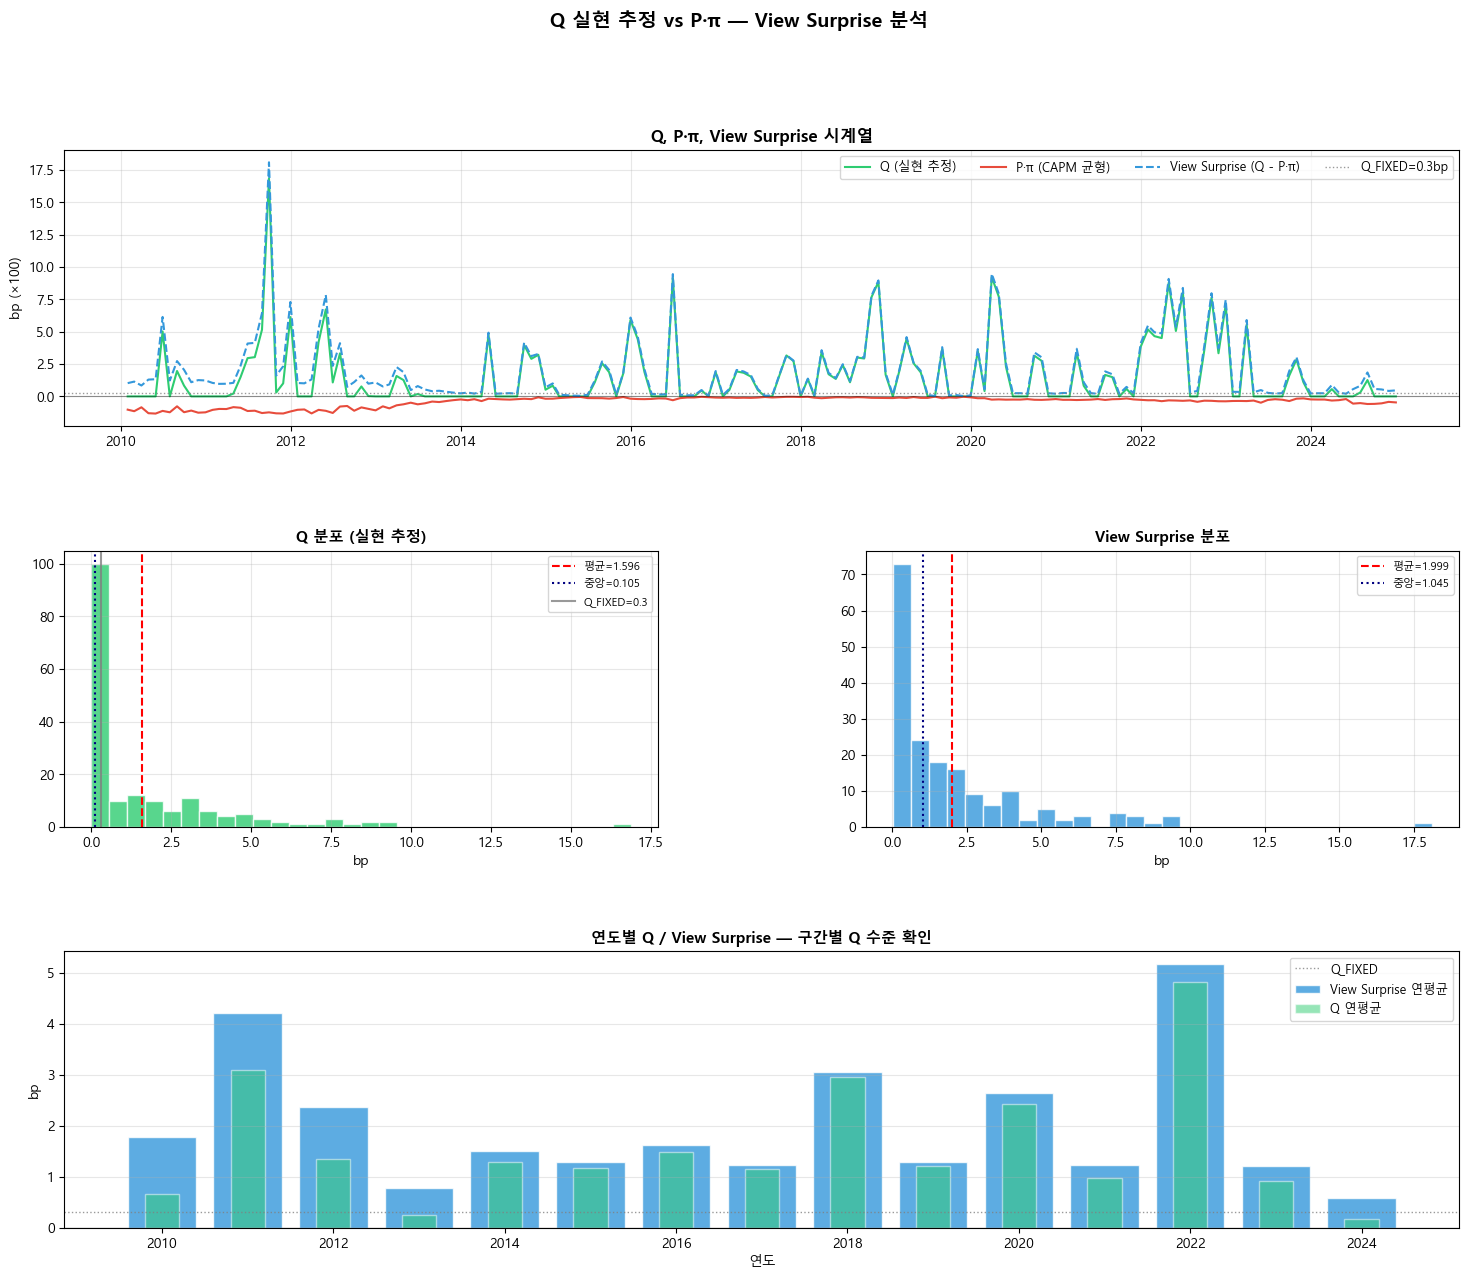

=== 수치 요약 ===
                Q        p_pi  view_surprise
count  180.000000  180.000000     180.000000
mean     0.015957   -0.004029       0.019985
std      0.025092    0.003801       0.025467
min      0.000000   -0.013284       0.000215
25%      0.000000   -0.005349       0.002544
50%      0.001050   -0.002487       0.010446
75%      0.025649   -0.001294       0.027103
max      0.168772   -0.000215       0.181107


In [8]:
# ── Q / P·π / view_surprise 시각화 ──────────────────────────
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# 1행: 시계열
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(q_pi_df.index, q_pi_df['Q'] * 100,             color='#2ecc71', lw=1.5, label='Q (실현 추정)')
ax1.plot(q_pi_df.index, q_pi_df['p_pi'] * 100,          color='#e74c3c', lw=1.5, label='P·π (CAPM 균형)')
ax1.plot(q_pi_df.index, q_pi_df['view_surprise'] * 100, color='#3498db', lw=1.5, linestyle='--', label='View Surprise (Q - P·π)')
ax1.axhline(0,           color='black', lw=0.8, alpha=0.4)
ax1.axhline(Q_FIXED*100, color='gray',  lw=1.0, linestyle=':', alpha=0.8, label=f'Q_FIXED={Q_FIXED*100:.1f}bp')
ax1.set_title('Q, P·π, View Surprise 시계열', fontweight='bold', fontsize=12)
ax1.set_ylabel('bp (×100)')
ax1.legend(fontsize=9, ncol=4); ax1.grid(alpha=0.3)

# 2행: 분포
for ci, (col, label, color) in enumerate([
    ('Q',             'Q 분포 (실현 추정)',   '#2ecc71'),
    ('view_surprise', 'View Surprise 분포',   '#3498db'),
]):
    ax = fig.add_subplot(gs[1, ci])
    vals = q_pi_df[col] * 100
    ax.hist(vals, bins=30, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(vals.mean(),   color='red',  lw=1.5, linestyle='--', label=f'평균={vals.mean():.3f}')
    ax.axvline(vals.median(), color='navy', lw=1.5, linestyle=':',  label=f'중앙={vals.median():.3f}')
    if col == 'Q':
        ax.axvline(Q_FIXED*100, color='gray', lw=1.5, alpha=0.8, label=f'Q_FIXED={Q_FIXED*100:.1f}')
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.set_xlabel('bp'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 3행: 연도별 평균
ax3 = fig.add_subplot(gs[2, :])
yr_vs = q_pi_df['view_surprise'].resample('YE').mean() * 100
yr_q  = q_pi_df['Q'].resample('YE').mean() * 100
x = range(len(yr_vs))
ax3.bar(yr_vs.index.year, yr_vs.values, color='#3498db', edgecolor='white', alpha=0.8, label='View Surprise 연평균')
ax3.bar(yr_q.index.year,  yr_q.values,  color='#2ecc71', edgecolor='white', alpha=0.5, label='Q 연평균', width=0.4)
ax3.axhline(0,           color='black', lw=0.8)
ax3.axhline(Q_FIXED*100, color='gray',  lw=1.0, linestyle=':', alpha=0.8, label='Q_FIXED')
ax3.set_title('연도별 Q / View Surprise — 구간별 Q 수준 확인', fontweight='bold', fontsize=11)
ax3.set_ylabel('bp'); ax3.set_xlabel('연도')
ax3.legend(fontsize=9); ax3.grid(axis='y', alpha=0.3)

plt.suptitle('Q 실현 추정 vs P·π — View Surprise 분석', fontsize=14, fontweight='bold')
plt.savefig(OUT_DIR / 'q_ppi_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print('=== 수치 요약 ===')
print(q_pi_df[['Q','p_pi','view_surprise']].describe().round(6).to_string())


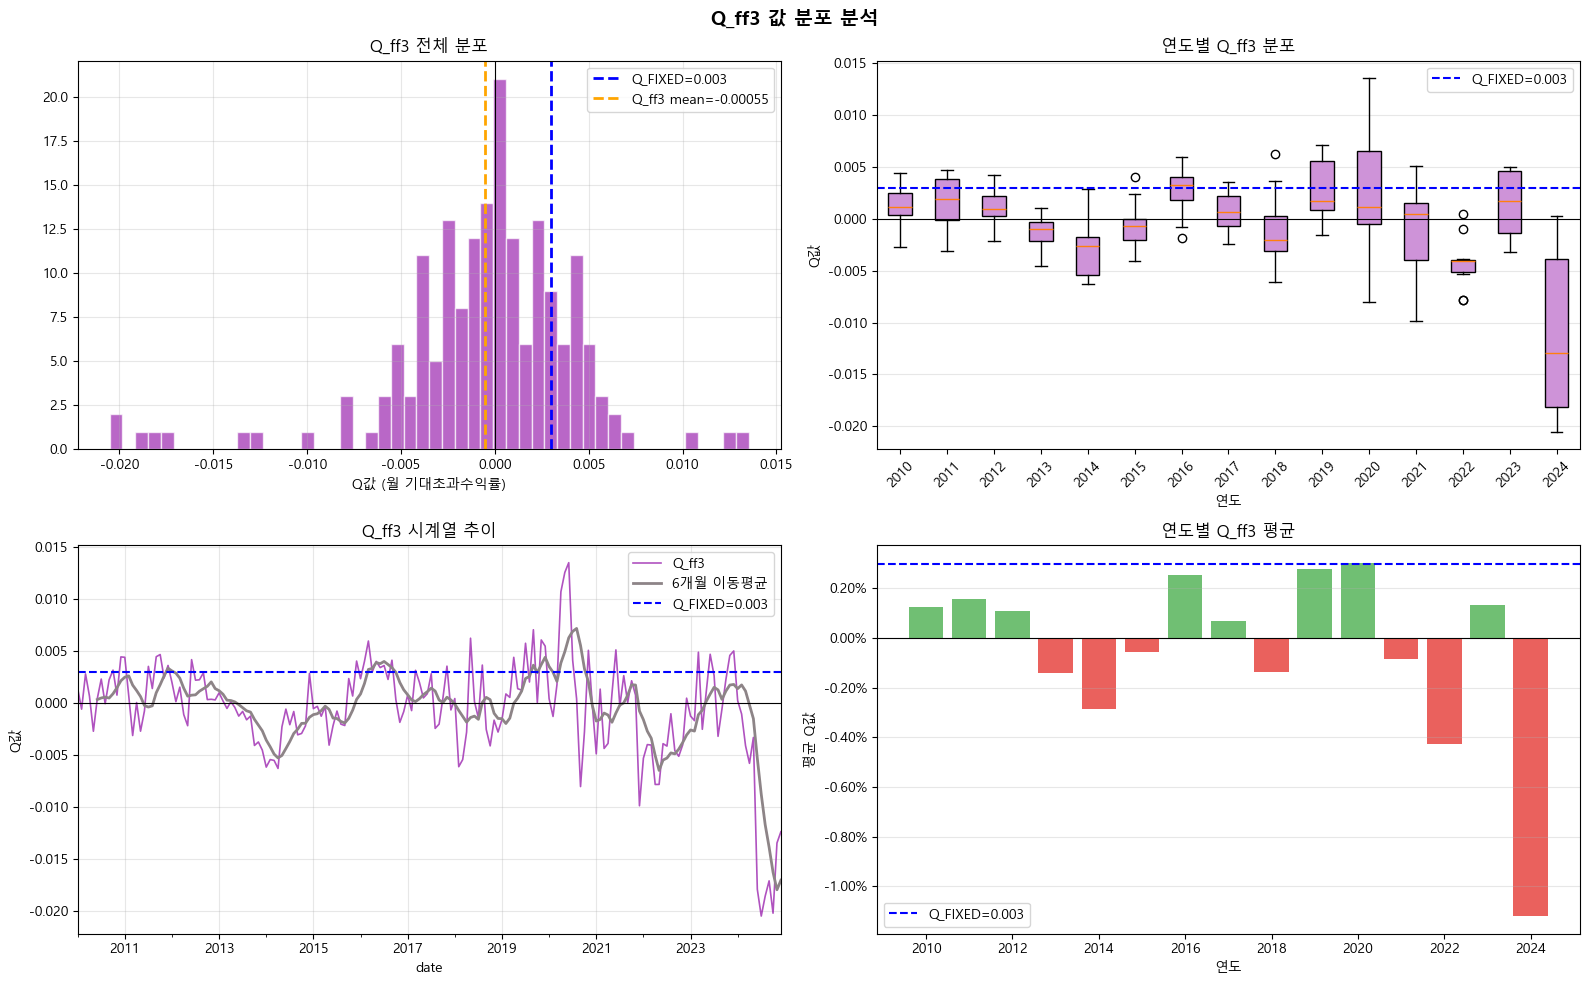

Q_ff3 통계 요약
  평균    : -0.00055  (Q_FIXED: 0.003)
  중앙값  : 0.00006
  표준편차: 0.00493
  최솟값  : -0.02052
  최댓값  : 0.01353
  음수 비율: 48.9%
  Q_FIXED보다 큰 비율: 19.4%

연도별 평균 Q_ff3
  2010: +0.00125  ─
  2011: +0.00156  ─
  2012: +0.00108  ─
  2013: -0.00141  ▼
  2014: -0.00287  ▼
  2015: -0.00054  ▼
  2016: +0.00254  ─
  2017: +0.00070  ─
  2018: -0.00136  ▼
  2019: +0.00278  ─
  2020: +0.00303  ▲
  2021: -0.00086  ▼
  2022: -0.00428  ▼
  2023: +0.00134  ─
  2024: -0.01120  ▼


In [9]:
# ── Q_ff3 값 분포 분석 ────────────────────────────────────────
q_series = q_ff3_df['Q'].copy()
q_series.index = pd.to_datetime(q_series.index)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Q_ff3 값 분포 분석', fontweight='bold', fontsize=14)

# ① 전체 분포 히스토그램
ax = axes[0, 0]
ax.hist(q_series, bins=50, color='#9C27B0', alpha=0.7, edgecolor='white')
ax.axvline(0.003,            color='blue',   linestyle='--', linewidth=2, label=f'Q_FIXED=0.003')
ax.axvline(q_series.mean(), color='orange', linestyle='--', linewidth=2,
           label=f'Q_ff3 mean={q_series.mean():.5f}')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Q_ff3 전체 분포')
ax.set_xlabel('Q값 (월 기대초과수익률)')
ax.legend()
ax.grid(True, alpha=0.3)

# ② 연도별 boxplot
ax = axes[0, 1]
years = sorted(q_series.index.year.unique())
yearly_data = [q_series[q_series.index.year == y].values for y in years]
bp = ax.boxplot(yearly_data, labels=years, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#CE93D8')
ax.axhline(0.003, color='blue',   linestyle='--', linewidth=1.5, label='Q_FIXED=0.003')
ax.axhline(0,     color='black',  linewidth=0.8)
ax.set_title('연도별 Q_ff3 분포')
ax.set_xlabel('연도')
ax.set_ylabel('Q값')
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# ③ 시계열 추이
ax = axes[1, 0]
q_series.plot(ax=ax, color='#9C27B0', linewidth=1.2, alpha=0.8, label='Q_ff3')
q_series.rolling(6).mean().plot(ax=ax, color="#8D8487", linewidth=2.0, label='6개월 이동평균')
ax.axhline(0.003, color='blue',  linestyle='--', linewidth=1.5, label='Q_FIXED=0.003')
ax.axhline(0,     color='black', linewidth=0.8)
ax.set_title('Q_ff3 시계열 추이')
ax.set_ylabel('Q값')
ax.legend()
ax.grid(True, alpha=0.3)

# ④ 연도별 평균 Q 막대그래프
ax = axes[1, 1]
yearly_mean = q_series.resample('YE').mean()
colors_bar  = ['#E53935' if v < 0 else '#4CAF50' for v in yearly_mean.values]
ax.bar(yearly_mean.index.year, yearly_mean.values, color=colors_bar, alpha=0.8)
ax.axhline(0.003, color='blue',  linestyle='--', linewidth=1.5, label='Q_FIXED=0.003')
ax.axhline(0,     color='black', linewidth=0.8)
ax.set_title('연도별 Q_ff3 평균')
ax.set_xlabel('연도')
ax.set_ylabel('평균 Q값')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig(OUT_DIR / 'q_ff3_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 통계 요약
print('Q_ff3 통계 요약')
print(f'  평균    : {q_series.mean():.5f}  (Q_FIXED: 0.003)')
print(f'  중앙값  : {q_series.median():.5f}')
print(f'  표준편차: {q_series.std():.5f}')
print(f'  최솟값  : {q_series.min():.5f}')
print(f'  최댓값  : {q_series.max():.5f}')
print(f'  음수 비율: {(q_series < 0).mean():.1%}')
print(f'  Q_FIXED보다 큰 비율: {(q_series > 0.003).mean():.1%}')
print()
print('연도별 평균 Q_ff3')
for y, v in yearly_mean.items():
    sign = '▲' if v > 0.003 else ('▼' if v < 0 else '─')
    print(f'  {y.year}: {v:+.5f}  {sign}')

Q 추정 방식 비교: Q_FIXED=0.003 vs Q_ff3 (per-stock regression)

[BL (Q_FIXED=0.003)]
  Sharpe: 1.182  연수익: 14.20%  변동성: 10.98%  MDD: -12.69%

[BL (Q_ff3)]
  Sharpe: 0.927  연수익: 14.32%  변동성: 14.15%  MDD: -24.42%

[S&P 500]
  Sharpe: 0.908  연수익: 14.35%  변동성: 14.54%  MDD: -23.93%

연도별 수익률 비교
    연도   Q_FIXED     Q_ff3        차이  Q_ff3 우위
  ------------------------------------------------
  2010  +16.21%   +16.48%   +0.27%  ▲
  2011  +7.77%   +5.04%   -2.74%  ▼
  2012  +22.25%   +21.92%   -0.33%  ▼
  2013  +21.10%   +27.92%   +6.83%  ▲
  2014  +22.97%   +16.61%   -6.36%  ▼
  2015  +9.30%   +5.43%   -3.87%  ▼
  2016  +13.81%   +15.45%   +1.64%  ▲
  2017  +16.75%   +22.58%   +5.83%  ▲
  2018  +1.81%   -7.13%   -8.94%  ▼
  2019  +22.34%   +29.41%   +7.07%  ▲
  2020  +17.95%   +19.91%   +1.96%  ▲
  2021  +28.86%   +32.85%   +3.99%  ▲
  2022  +3.15%   -12.95%   -16.09%  ▼
  2023  +1.66%   +8.15%   +6.49%  ▲
  2024  +15.74%   +21.87%   +6.13%  ▲


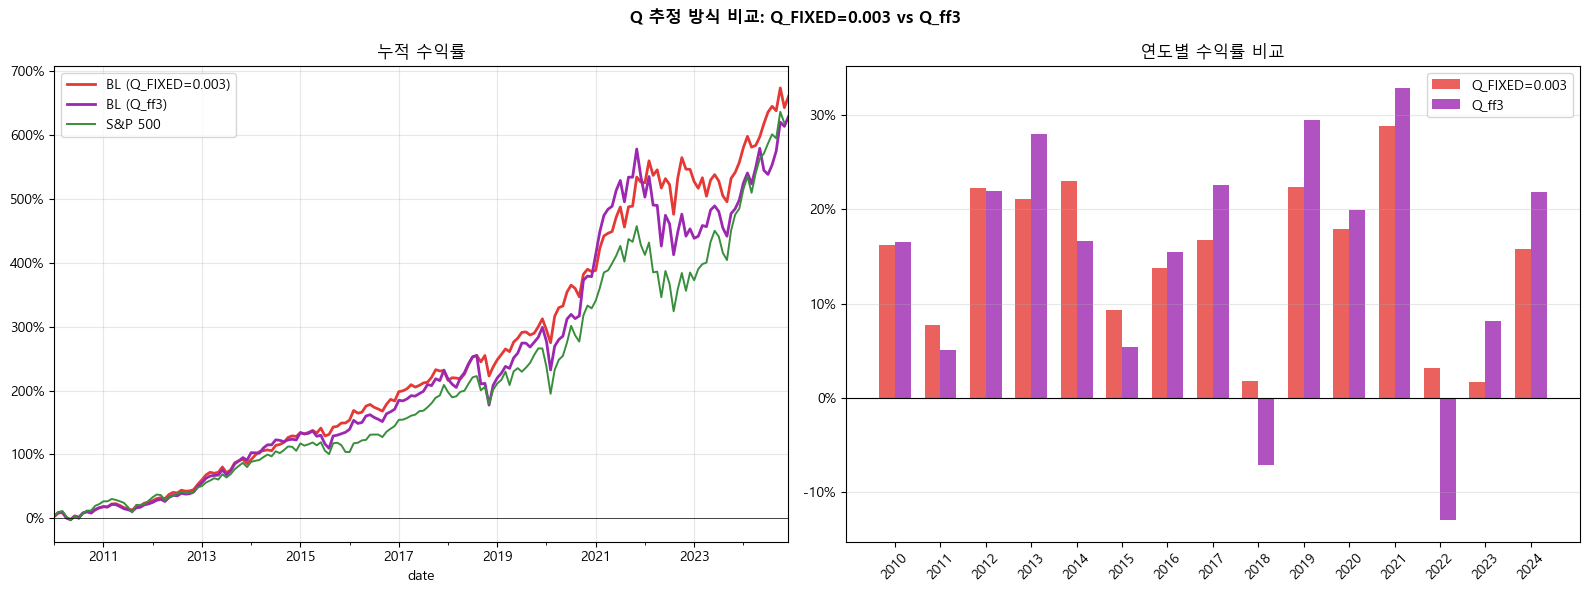

저장 완료: bl_q_comparison.png


In [10]:
# ── Q_FIXED vs Q_ff3 성과 비교 ───────────────────────────────
rf_monthly_full = panel['rf_1m'].groupby(level='date').first()

common_dates = bl_ret.index.intersection(bl_ff3_ret.index)
bl_fixed_c   = bl_ret.reindex(common_dates)
bl_ff3_c     = bl_ff3_ret.reindex(common_dates)
spy_c        = spy_ret.reindex(common_dates)
rf_c         = rf_monthly_full.reindex(common_dates).fillna(0)

print('=' * 65)
print('Q 추정 방식 비교: Q_FIXED=0.003 vs Q_ff3 (per-stock regression)')
print('=' * 65)

portfolios_q = [
    (bl_fixed_c, 'BL (Q_FIXED=0.003)', '#E53935'),
    (bl_ff3_c,   'BL (Q_ff3)',          '#9C27B0'),
    (spy_c,      'S&P 500',             '#388E3C'),
]

for ret, label, _ in portfolios_q:
    exc = ret - rf_c
    sr  = exc.mean() / exc.std() * np.sqrt(12)
    ar  = ret.mean() * 12
    av  = ret.std() * np.sqrt(12)
    cum = (1 + ret).cumprod()
    mdd = ((cum - cum.cummax()) / cum.cummax()).min()
    print(f'\n[{label}]')
    print(f'  Sharpe: {sr:.3f}  연수익: {ar:.2%}  변동성: {av:.2%}  MDD: {mdd:.2%}')

# 연도별 수익률 비교 테이블
print('\n연도별 수익률 비교')
print(f'  {"연도":>4}  {"Q_FIXED":>8}  {"Q_ff3":>8}  {"차이":>8}  {"Q_ff3 우위"}')
print('  ' + '-' * 48)
bl_fixed_y = bl_fixed_c.copy(); bl_fixed_y.index = pd.to_datetime(bl_fixed_y.index)
bl_ff3_y   = bl_ff3_c.copy();   bl_ff3_y.index   = pd.to_datetime(bl_ff3_y.index)

for year in sorted(bl_fixed_y.index.year.unique()):
    r_fix  = (1 + bl_fixed_y[bl_fixed_y.index.year == year]).prod() - 1
    r_ff3  = (1 + bl_ff3_y[bl_ff3_y.index.year == year]).prod() - 1
    diff   = r_ff3 - r_fix
    marker = '▲' if diff > 0 else '▼'
    print(f'  {year}  {r_fix:+.2%}   {r_ff3:+.2%}   {diff:+.2%}  {marker}')

# ── 시각화 ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Q 추정 방식 비교: Q_FIXED=0.003 vs Q_ff3', fontweight='bold')

ax = axes[0]
for ret, label, color in portfolios_q:
    lw = 2.0 if 'BL' in label else 1.4
    (1 + ret).cumprod().sub(1).plot(ax=ax, label=label, color=color, linewidth=lw)
ax.set_title('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
ax.axhline(0, color='k', lw=0.5)
ax.grid(True, alpha=0.3)

ax = axes[1]
years_list = sorted(bl_fixed_y.index.year.unique())
x     = np.arange(len(years_list))
width = 0.35
fix_ann = [(1 + bl_fixed_y[bl_fixed_y.index.year == y]).prod() - 1 for y in years_list]
ff3_ann = [(1 + bl_ff3_y[bl_ff3_y.index.year == y]).prod() - 1   for y in years_list]
ax.bar(x - width/2, fix_ann, width, label='Q_FIXED=0.003', color='#E53935', alpha=0.8)
ax.bar(x + width/2, ff3_ann, width, label='Q_ff3',         color='#9C27B0', alpha=0.8)
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(years_list, rotation=45)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('연도별 수익률 비교')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUT_DIR / 'bl_q_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: bl_q_comparison.png')

In [11]:
# ── 성과 분석 ────────────────────────────────────────────────
ANN = np.sqrt(12)

rf_monthly = panel['rf_1m'].groupby(level='date').first().reindex(bl_ret.index).fillna(0)

def performance(ret, rf, label):
    excess   = ret - rf
    ann_ret  = ret.mean() * 12
    ann_vol  = ret.std() * ANN
    sharpe   = excess.mean() / excess.std() * ANN
    cum_ret  = (1 + ret).prod() - 1
    # MDD
    cum      = (1 + ret).cumprod()
    peak     = cum.cummax()
    drawdown = (cum - peak) / peak
    mdd      = drawdown.min()
    print(f'[{label}]')
    print(f'  연환산 수익률: {ann_ret:.2%}')
    print(f'  연환산 변동성: {ann_vol:.2%}')
    print(f'  Sharpe Ratio:  {sharpe:.3f}')
    print(f'  누적 수익률:   {cum_ret:.2%}')
    print(f'  MDD:           {mdd:.2%}')
    return {'label': label, 'ann_ret': ann_ret, 'ann_vol': ann_vol,
            'sharpe': sharpe, 'cum_ret': cum_ret, 'mdd': mdd}

print('=' * 55)
print('포트폴리오 성과 비교')
print('=' * 55)
stats = []
for ret, label in [(bl_ret, 'BL Baseline'), (capm_ret, 'CAPM 균형'), (spy_ret, 'S&P 500')]:
    stats.append(performance(ret, rf_monthly, label))
    print()

포트폴리오 성과 비교
[BL Baseline]
  연환산 수익률: 14.20%
  연환산 변동성: 10.98%
  Sharpe Ratio:  1.182
  누적 수익률:   660.72%
  MDD:           -12.69%

[CAPM 균형]
  연환산 수익률: 14.91%
  연환산 변동성: 15.14%
  Sharpe Ratio:  0.907
  누적 수익률:   679.71%
  MDD:           -22.16%

[S&P 500]
  연환산 수익률: 14.35%
  연환산 변동성: 14.54%
  Sharpe Ratio:  0.908
  누적 수익률:   618.96%
  MDD:           -23.93%



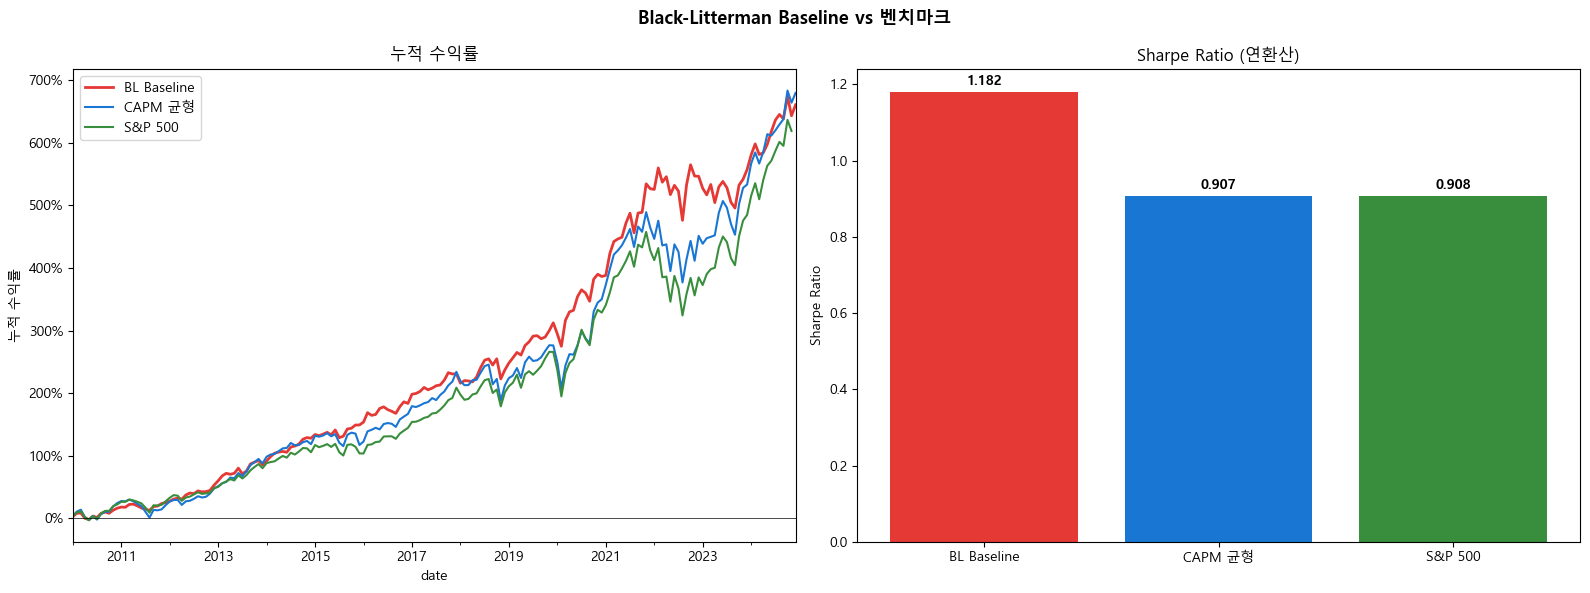

결과 저장 완료


In [12]:
# ── 시각화 ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Black-Litterman Baseline vs 벤치마크', fontsize=13, fontweight='bold')

# ① 누적 수익률
ax = axes[0]
for ret, label, color, lw in [
    (bl_ret,   'BL Baseline', '#E53935', 2.0),
    (capm_ret, 'CAPM 균형',   '#1976D2', 1.5),
    (spy_ret,  'S&P 500',     '#388E3C', 1.5),
]:
    cum = (1 + ret).cumprod() - 1
    cum.plot(ax=ax, label=label, color=color, linewidth=lw)
ax.set_title('누적 수익률')
ax.set_ylabel('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)

# ② Sharpe Ratio 막대
ax = axes[1]
labels  = [s['label']  for s in stats]
sharpes = [s['sharpe'] for s in stats]
colors  = ['#E53935', '#1976D2', '#388E3C']
bars    = ax.bar(labels, sharpes, color=colors)
ax.set_title('Sharpe Ratio (연환산)')
ax.set_ylabel('Sharpe Ratio')
ax.axhline(0, color='black', linewidth=0.5)
for bar, val in zip(bars, sharpes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / 'bl_baseline_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# 결과 저장
result_df = pd.DataFrame({'bl': bl_ret, 'capm': capm_ret, 'spy': spy_ret})
result_df.to_csv(DATA_DIR / 'bl_baseline_returns.csv')
print('결과 저장 완료')

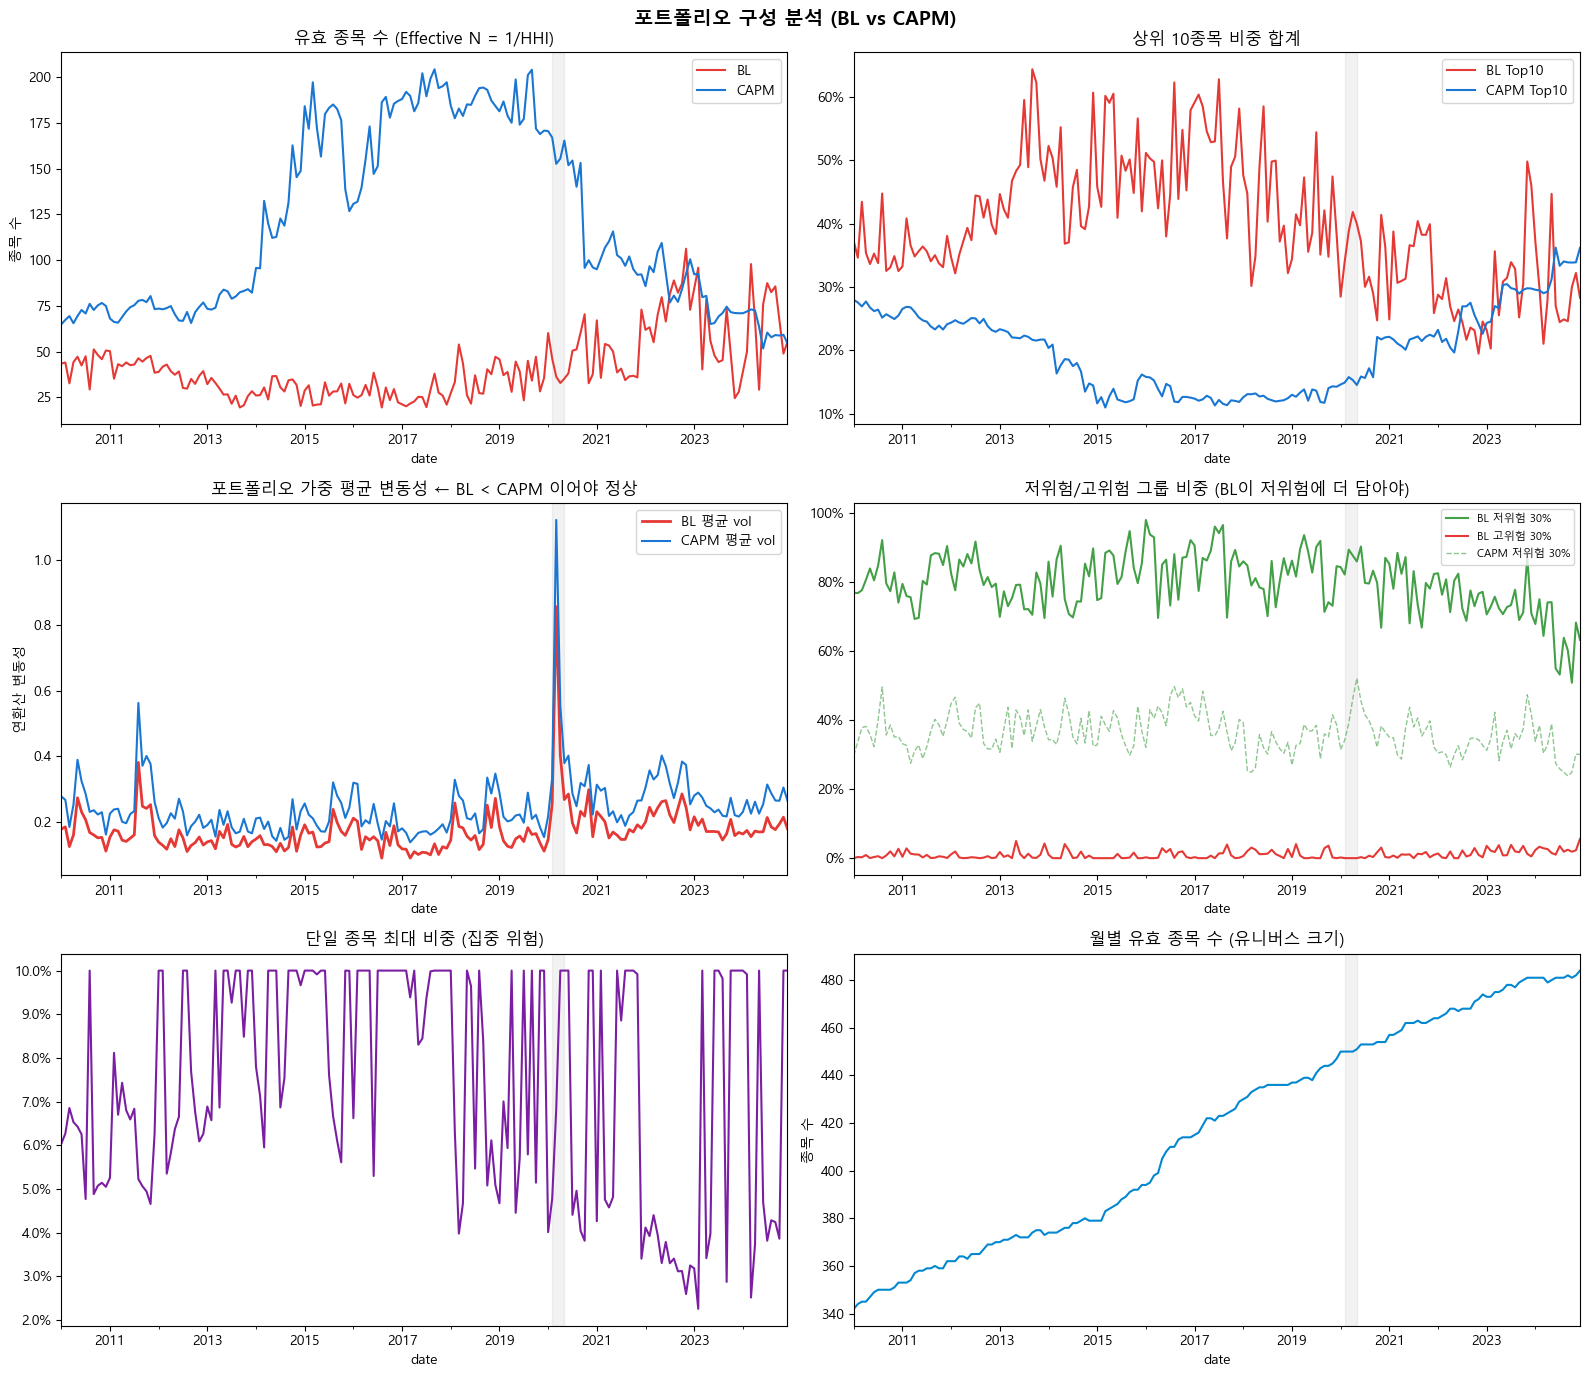

=== BL vs CAPM 구성 비교 ===
유효 종목 수:      BL 41.5개  /  CAPM 119.3개
Top10 집중도:      BL 39.9%  /  CAPM 20.2%
단일 최대 비중:    BL 7.4%
평균 변동성:       BL 0.1736  /  CAPM 0.2470  ← BL이 낮아야 정상
저위험 그룹 비중:  BL 79.8%  /  CAPM 36.2%
고위험 그룹 비중:  BL 1.0%  /  CAPM 23.0%


In [13]:
# ── 포트폴리오 구성 시각화 ───────────────────────────────────
crisis = [('2020-02-01', '2020-05-01', 'COVID')]

def shade(ax):
    for s, e, label in crisis:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.1, color='gray', label=label)

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('포트폴리오 구성 분석 (BL vs CAPM)', fontsize=14, fontweight='bold')

# ① 유효 종목 수
ax = axes[0, 0]
comp['bl_eff_n'].plot(ax=ax, color='#E53935', label='BL', linewidth=1.5)
comp['capm_eff_n'].plot(ax=ax, color='#1976D2', label='CAPM', linewidth=1.5)
ax.set_title('유효 종목 수 (Effective N = 1/HHI)')
ax.set_ylabel('종목 수')
ax.legend(); shade(ax)

# ② 상위 10종목 집중도
ax = axes[0, 1]
comp['bl_top10_share'].plot(ax=ax, color='#E53935', label='BL Top10', linewidth=1.5)
comp['capm_top10_share'].plot(ax=ax, color='#1976D2', label='CAPM Top10', linewidth=1.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('상위 10종목 비중 합계')
ax.legend(); shade(ax)

# ③ 포트폴리오 평균 변동성 ← 핵심: BL < CAPM 이어야 저위험 틸트 확인
ax = axes[1, 0]
comp['bl_avg_vol'].plot(ax=ax, color='#E53935', label='BL 평균 vol', linewidth=2.0)
comp['capm_avg_vol'].plot(ax=ax, color='#1976D2', label='CAPM 평균 vol', linewidth=1.5)
ax.set_title('포트폴리오 가중 평균 변동성 ← BL < CAPM 이어야 정상')
ax.set_ylabel('연환산 변동성')
ax.legend(); shade(ax)

# ④ 저위험/고위험 그룹 비중
ax = axes[1, 1]
comp['bl_low_weight'].plot(ax=ax, color='#43A047', label='BL 저위험 30%', linewidth=1.5)
comp['bl_high_weight'].plot(ax=ax, color='#E53935', label='BL 고위험 30%', linewidth=1.5)
comp['capm_low_weight'].plot(ax=ax, color='#43A047', linestyle='--',
                              label='CAPM 저위험 30%', linewidth=1.0, alpha=0.6)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('저위험/고위험 그룹 비중 (BL이 저위험에 더 담아야)')
ax.legend(fontsize=8); shade(ax)

# ⑤ 단일 최대 비중
ax = axes[2, 0]
comp['bl_top1_weight'].plot(ax=ax, color='#7B1FA2', linewidth=1.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('단일 종목 최대 비중 (집중 위험)')
shade(ax)

# ⑥ 유니버스 크기
ax = axes[2, 1]
comp['n_stocks'].plot(ax=ax, color='#0288D1', linewidth=1.5)
ax.set_title('월별 유효 종목 수 (유니버스 크기)')
ax.set_ylabel('종목 수')
shade(ax)

plt.tight_layout()
plt.savefig(OUT_DIR / 'portfolio_composition.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 수치 요약 ─────────────────────────────────────────────────
print('=== BL vs CAPM 구성 비교 ===')
print(f"유효 종목 수:      BL {comp['bl_eff_n'].mean():.1f}개  /  CAPM {comp['capm_eff_n'].mean():.1f}개")
print(f"Top10 집중도:      BL {comp['bl_top10_share'].mean():.1%}  /  CAPM {comp['capm_top10_share'].mean():.1%}")
print(f"단일 최대 비중:    BL {comp['bl_top1_weight'].mean():.1%}")
print(f"평균 변동성:       BL {comp['bl_avg_vol'].mean():.4f}  /  CAPM {comp['capm_avg_vol'].mean():.4f}  ← BL이 낮아야 정상")
print(f"저위험 그룹 비중:  BL {comp['bl_low_weight'].mean():.1%}  /  CAPM {comp['capm_low_weight'].mean():.1%}")
print(f"고위험 그룹 비중:  BL {comp['bl_high_weight'].mean():.1%}  /  CAPM {comp['capm_high_weight'].mean():.1%}")

BL Baseline vs 단순 저변동성 포트폴리오

[BL Baseline       (vol_21d + BL 최적화)]
  Sharpe: 1.182  연수익: 14.20%  변동성: 10.98%  MDD: -12.69%

[단순 저변동성     (vol_21d 하위30% 시총가중)]
  Sharpe: 1.113  연수익: 14.63%  변동성: 12.05%  MDD: -14.38%

[CAPM 균형         (전체 시총가중)]
  Sharpe: 0.907  연수익: 14.91%  변동성: 15.14%  MDD: -22.16%

[S&P 500]
  Sharpe: 0.908  연수익: 14.35%  변동성: 14.54%  MDD: -23.93%


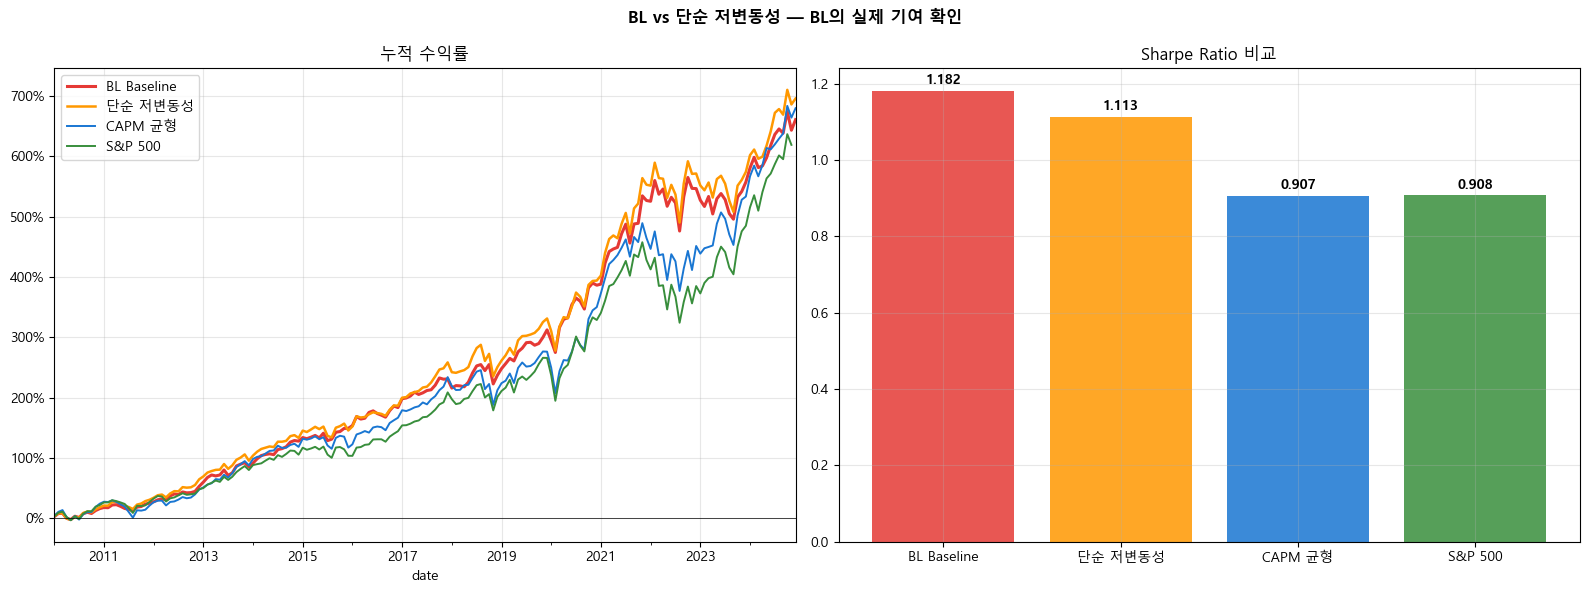

In [14]:
# ── 단순 저변동성 포트폴리오 (naive low-vol benchmark) ──────────
# BL 없이 그냥 vol_21d 하위 30% 시총가중 보유
# → BL이 기여하는지 vs 저변동성 선택 자체의 효과인지 분리

naive_lowvol_returns = []

for i, pred_date in enumerate(pred_dates):
    try:
        month_df = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'fwd_ret_1m'])
        if len(month_df) < 30:
            continue

        n_group   = max(1, int(len(month_df) * PCT_GROUP))
        low_tix   = month_df['vol_21d'].sort_values().index[:n_group]
        mcap_low  = np.exp(month_df.loc[low_tix, 'log_mcap'])
        w_naive   = mcap_low / mcap_low.sum()
        ret_naive = float(w_naive @ month_df.loc[low_tix, 'fwd_ret_1m'].fillna(0))
        naive_lowvol_returns.append({'date': pred_date, 'ret': ret_naive})
    except:
        pass

naive_ret = pd.DataFrame(naive_lowvol_returns).set_index('date')['ret']

# ── 성과 비교 ─────────────────────────────────────────────────
print('=' * 60)
print('BL Baseline vs 단순 저변동성 포트폴리오')
print('=' * 60)
rf_m = panel['rf_1m'].groupby(level='date').first().reindex(bl_ret.index).fillna(0)

for ret, label in [
    (bl_ret,   'BL Baseline       (vol_21d + BL 최적화)'),
    (naive_ret,'단순 저변동성     (vol_21d 하위30% 시총가중)'),
    (capm_ret, 'CAPM 균형         (전체 시총가중)'),
    (spy_ret,  'S&P 500'),
]:
    rf   = rf_m.reindex(ret.index).fillna(0)
    exc  = ret - rf
    sr   = exc.mean() / exc.std() * np.sqrt(12)
    ar   = ret.mean() * 12
    av   = ret.std() * np.sqrt(12)
    cum  = (1 + ret).cumprod()
    mdd  = ((cum - cum.cummax()) / cum.cummax()).min()
    print(f'\n[{label}]')
    print(f'  Sharpe: {sr:.3f}  연수익: {ar:.2%}  변동성: {av:.2%}  MDD: {mdd:.2%}')

# ── 시각화 ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('BL vs 단순 저변동성 — BL의 실제 기여 확인', fontweight='bold')

portfolios_cmp = [
    (bl_ret,    'BL Baseline',    '#E53935', 2.2),
    (naive_ret, '단순 저변동성',  '#FF9800', 1.8),
    (capm_ret,  'CAPM 균형',      '#1976D2', 1.4),
    (spy_ret,   'S&P 500',        '#388E3C', 1.4),
]

ax = axes[0]
for ret, label, color, lw in portfolios_cmp:
    (1 + ret).cumprod().sub(1).plot(ax=ax, label=label, color=color, linewidth=lw)
ax.set_title('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
ax.axhline(0, color='k', lw=0.5)
ax.grid(True, alpha=0.3)

ax = axes[1]
labels_bar  = [l for _, l, _, _ in portfolios_cmp]
sharpes_bar = []
for ret, label, color, lw in portfolios_cmp:
    rf  = rf_m.reindex(ret.index).fillna(0)
    exc = ret - rf
    sharpes_bar.append(exc.mean() / exc.std() * np.sqrt(12))
colors_bar = [c for _, _, c, _ in portfolios_cmp]
bars = ax.bar(labels_bar, sharpes_bar, color=colors_bar, alpha=0.85)
for bar, val in zip(bars, sharpes_bar):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Sharpe Ratio 비교')
ax.axhline(0, color='k', lw=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'bl_vs_naive_lowvol.png', dpi=150, bbox_inches='tight')
plt.show()

Prior 비교: 시총가중 vs 1/N 동일가중

[BL (시총가중 prior)    ]
  Sharpe: 1.182  연수익: 14.20%  변동성: 10.98%  MDD: -12.69%

[BL (1/N 동일가중 prior)]
  Sharpe: 1.183  연수익: 15.14%  변동성: 11.75%  MDD: -13.14%

[단순 저변동성 (BL 없음)]
  Sharpe: 1.113  연수익: 14.63%  변동성: 12.05%  MDD: -14.38%

[S&P 500               ]
  Sharpe: 0.908  연수익: 14.35%  변동성: 14.54%  MDD: -23.93%


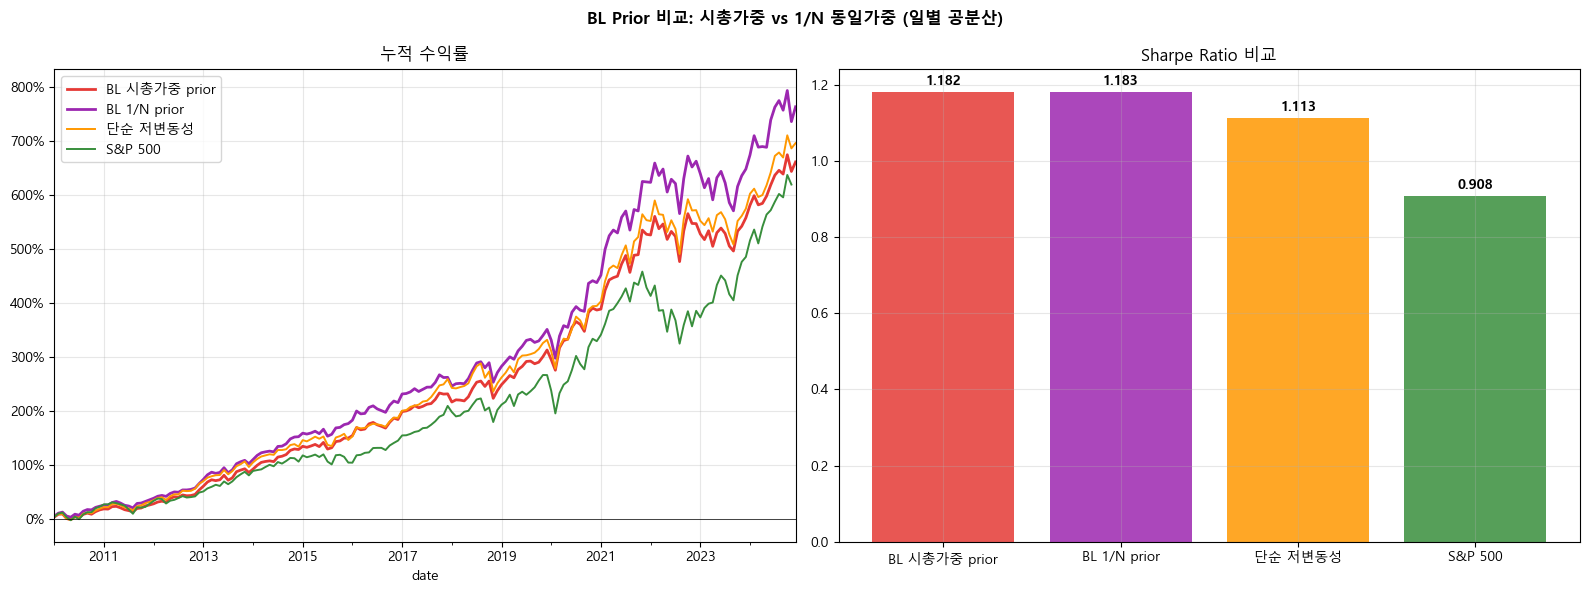

In [15]:
# ── Prior: 1/N (동일가중) vs 시총가중 비교 ───────────────────
# BL prior π = λΣw 에서 w를 시총 대신 동일가중으로 바꾼 버전

bl_eq_returns = []

for i, pred_date in enumerate(pred_dates):
    try:
        month_df = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_df) < 30:
            continue
        universe = month_df.index.tolist()

        # ── 일별 공분산 (cell-03과 동일) ──────────────────────
        daily_slice, valid_tix = compute_daily_slice(pred_date, universe)
        if len(valid_tix) < 20:
            continue
        Sigma = compute_sigma(daily_slice, scale=21)

        month_df = month_df.reindex(valid_tix)

        idx         = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
        spy_s       = spy_series.reindex(train_dates)
        rf_s        = rf_series.reindex(train_dates)
        spy_excess  = (spy_s - rf_s).mean()
        sigma2_mkt  = spy_s.var()

        # 1/N prior
        w_eq    = pd.Series(1.0 / len(valid_tix), index=valid_tix)
        pi_eq, lam = compute_pi(Sigma, w_eq, spy_excess, sigma2_mkt)

        mcap = np.exp(month_df['log_mcap'])
        P    = build_P(month_df['vol_21d'], mcap, pct=PCT_GROUP)
        P    = P.reindex(valid_tix).fillna(0)

        omega    = compute_omega(P, Sigma, TAU)
        mu_BL_eq = black_litterman(pi_eq, Sigma, P, Q_FIXED, omega, TAU)
        w_bl_eq  = optimize_portfolio(mu_BL_eq, Sigma, lam)

        actual_ret = month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0)
        bl_eq_returns.append({'date': pred_date, 'ret': float(w_bl_eq @ actual_ret)})

    except:
        pass

bl_eq_ret = pd.DataFrame(bl_eq_returns).set_index('date')['ret']

# ── 성과 비교 ─────────────────────────────────────────────────
print('=' * 60)
print('Prior 비교: 시총가중 vs 1/N 동일가중')
print('=' * 60)
rf_m = panel['rf_1m'].groupby(level='date').first()

for ret, label in [
    (bl_ret,    'BL (시총가중 prior)    '),
    (bl_eq_ret, 'BL (1/N 동일가중 prior)'),
    (naive_ret, '단순 저변동성 (BL 없음)'),
    (spy_ret,   'S&P 500               '),
]:
    rf  = rf_m.reindex(ret.index).fillna(0)
    exc = ret - rf
    sr  = exc.mean() / exc.std() * np.sqrt(12)
    ar  = ret.mean() * 12
    av  = ret.std() * np.sqrt(12)
    cum = (1 + ret).cumprod()
    mdd = ((cum - cum.cummax()) / cum.cummax()).min()
    print(f'\n[{label}]')
    print(f'  Sharpe: {sr:.3f}  연수익: {ar:.2%}  변동성: {av:.2%}  MDD: {mdd:.2%}')

# ── 시각화 ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('BL Prior 비교: 시총가중 vs 1/N 동일가중 (일별 공분산)', fontweight='bold')

portfolios_prior = [
    (bl_ret,    'BL 시총가중 prior', '#E53935', 2.0),
    (bl_eq_ret, 'BL 1/N prior',      '#9C27B0', 2.0),
    (naive_ret, '단순 저변동성',     '#FF9800', 1.4),
    (spy_ret,   'S&P 500',           '#388E3C', 1.4),
]

ax = axes[0]
for ret, label, color, lw in portfolios_prior:
    (1 + ret).cumprod().sub(1).plot(ax=ax, label=label, color=color, linewidth=lw)
ax.set_title('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
ax.axhline(0, color='k', lw=0.5)
ax.grid(True, alpha=0.3)

ax = axes[1]
labels_p, sharpes_p, colors_p = [], [], []
for ret, label, color, lw in portfolios_prior:
    rf  = rf_m.reindex(ret.index).fillna(0)
    exc = ret - rf
    labels_p.append(label)
    sharpes_p.append(exc.mean() / exc.std() * np.sqrt(12))
    colors_p.append(color)
bars = ax.bar(labels_p, sharpes_p, color=colors_p, alpha=0.85)
for bar, val in zip(bars, sharpes_p):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Sharpe Ratio 비교')
ax.axhline(0, color='k', lw=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'bl_prior_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

전략 계층별 비교: 선택 효과 vs 가중 방식 vs BL 기여

[BL (시총 prior)]
  Sharpe: 1.182  연수익: 14.20%  변동성: 10.98%  MDD: -12.69%

[BL (1/N prior)]
  Sharpe: 1.183  연수익: 15.14%  변동성: 11.75%  MDD: -13.14%

[1/N 등가중 (BL 없음)]
  Sharpe: 1.087  연수익: 14.57%  변동성: 12.28%  MDD: -15.19%

[시총가중 (BL 없음)]
  Sharpe: 1.113  연수익: 14.63%  변동성: 12.05%  MDD: -14.38%

[S&P 500]
  Sharpe: 0.908  연수익: 14.35%  변동성: 14.54%  MDD: -23.93%


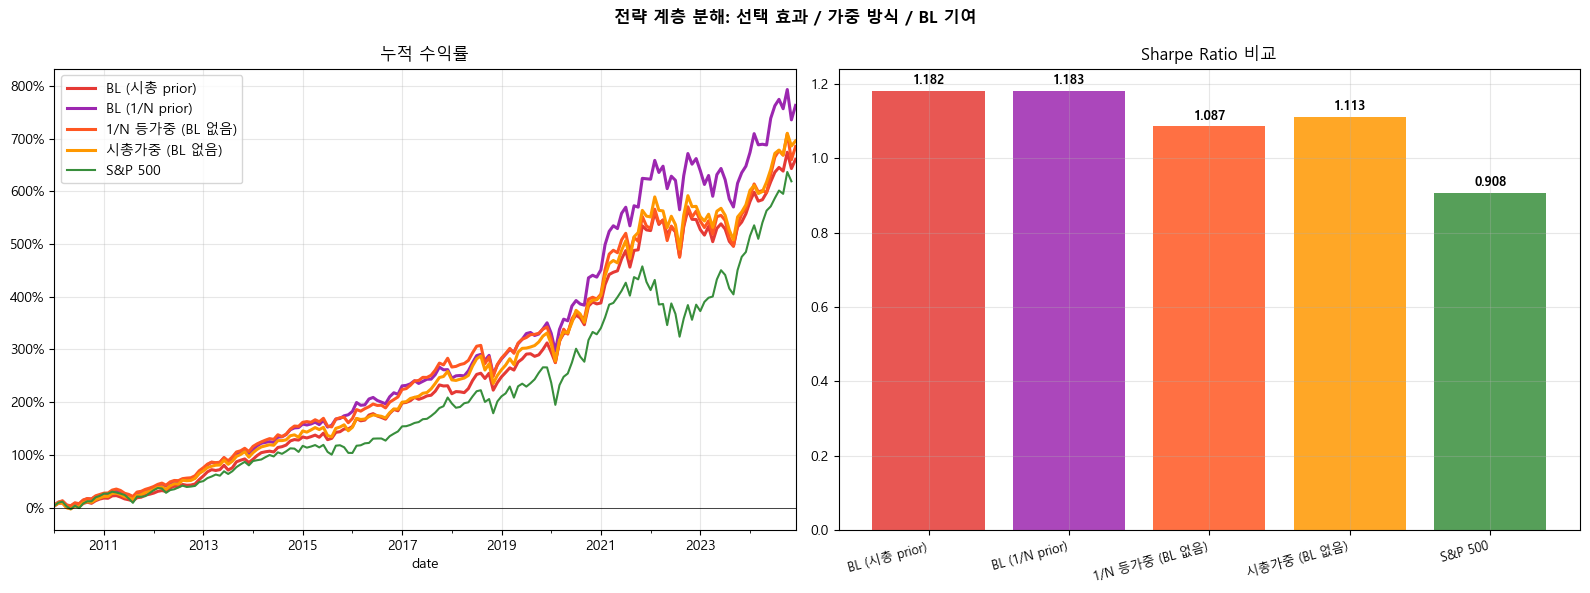

저장 완료: bl_strategy_decomposition.png


In [16]:
# ── 1/N 등가중 포트폴리오 (BL 없음, 저변동성 유니버스) ────────
# naive_ret: 저변동성 하위30% + 시총가중 (BL 없음)   → vol selection 효과
# eq_ret:    저변동성 하위30% + 동일가중 (BL 없음)   → 1/N 자체 효과
# bl_eq_ret: 저변동성 뷰 + 1/N prior + BL 최적화    → BL 추가 기여

eq_lowvol_returns = []

for pred_date in pred_dates:
    try:
        month_df = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'fwd_ret_1m'])
        if len(month_df) < 30:
            continue
        n_group  = max(1, int(len(month_df) * PCT_GROUP))
        low_tix  = month_df['vol_21d'].sort_values().index[:n_group]
        w_eq     = pd.Series(1.0 / len(low_tix), index=low_tix)
        ret_eq   = float(w_eq @ month_df.loc[low_tix, 'fwd_ret_1m'].fillna(0))
        eq_lowvol_returns.append({'date': pred_date, 'ret': ret_eq})
    except:
        pass

eq_ret = pd.DataFrame(eq_lowvol_returns).set_index('date')['ret']

# ── 전체 비교 ─────────────────────────────────────────────────
print('=' * 65)
print('전략 계층별 비교: 선택 효과 vs 가중 방식 vs BL 기여')
print('=' * 65)

all_cmp = [
    (bl_ret,    'BL (시총 prior)',         '#E53935'),
    (bl_eq_ret, 'BL (1/N prior)',          '#9C27B0'),
    (eq_ret,    '1/N 등가중 (BL 없음)',    '#FF5722'),
    (naive_ret, '시총가중 (BL 없음)',      '#FF9800'),
    (spy_ret,   'S&P 500',                 '#388E3C'),
]

for ret, label, _ in all_cmp:
    rf  = rf_m.reindex(ret.index).fillna(0)
    exc = ret - rf
    sr  = exc.mean() / exc.std() * np.sqrt(12)
    ar  = ret.mean() * 12
    av  = ret.std() * np.sqrt(12)
    cum = (1 + ret).cumprod()
    mdd = ((cum - cum.cummax()) / cum.cummax()).min()
    print(f'\n[{label}]')
    print(f'  Sharpe: {sr:.3f}  연수익: {ar:.2%}  변동성: {av:.2%}  MDD: {mdd:.2%}')

# ── 시각화 ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('전략 계층 분해: 선택 효과 / 가중 방식 / BL 기여', fontweight='bold')

ax = axes[0]
for ret, label, color in all_cmp:
    lw = 2.2 if 'BL' in label else 1.5
    (1 + ret).cumprod().sub(1).plot(ax=ax, label=label, color=color, linewidth=lw)
ax.set_title('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
ax.axhline(0, color='k', lw=0.5)
ax.grid(True, alpha=0.3)

ax = axes[1]
labels_b, sharpes_b, colors_b = [], [], []
for ret, label, color in all_cmp:
    rf  = rf_m.reindex(ret.index).fillna(0)
    exc = ret - rf
    labels_b.append(label)
    sharpes_b.append(exc.mean() / exc.std() * np.sqrt(12))
    colors_b.append(color)
bars = ax.bar(labels_b, sharpes_b, color=colors_b, alpha=0.85)
for bar, val in zip(bars, sharpes_b):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Sharpe Ratio 비교')
ax.set_xticklabels(labels_b, rotation=15, ha='right', fontsize=9)
ax.axhline(0, color='k', lw=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'bl_strategy_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: bl_strategy_decomposition.png')